# Inventory overstock as a leading indicator

Publication-quality predictive analytics visualization: Days of Supply hi?n t?i vs. doanh thu k? ti?p theo.

## 1. Setup
Load libraries, define paths, and configure output locations.

In [128]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Works when the notebook is executed either from repo root or from ai_eda/.
ROOT = Path.cwd() if Path.cwd().name == "ai_eda" else Path.cwd() / "ai_eda"
DATA_DIR = ROOT / "datathon-2026-round-1"
OUTPUT_DIR = ROOT / "report_visuals"

## 2. Build monthly lead-lag dataset
Aggregate inventory and revenue by month, then shift revenue forward one period.

In [129]:
def build_monthly_dataset() -> pd.DataFrame:
    inventory = pd.read_csv(DATA_DIR / "inventory.csv", parse_dates=["snapshot_date"])
    sales = pd.read_csv(DATA_DIR / "sales.csv", parse_dates=["Date"])

    inventory["period"] = inventory["snapshot_date"].dt.to_period("M").dt.to_timestamp()
    sales["period"] = sales["Date"].dt.to_period("M").dt.to_timestamp()

    monthly_inventory = (
        inventory.groupby("period", as_index=False)
        .agg(
            days_of_supply=("days_of_supply", "mean"),
            inventory_units=("stock_on_hand", "sum"),
            overstock_rate=("overstock_flag", "mean"),
        )
        .sort_values("period")
    )
    monthly_revenue = (
        sales.groupby("period", as_index=False)
        .agg(revenue=("Revenue", "sum"))
        .sort_values("period")
    )

    dataset = monthly_inventory.merge(monthly_revenue, on="period", how="inner")
    dataset["future_revenue"] = dataset["revenue"].shift(-1)
    dataset = dataset.dropna(subset=["days_of_supply", "future_revenue"]).copy()
    dataset["future_revenue_m"] = dataset["future_revenue"] / 1_000_000
    dataset["period_label"] = dataset["period"].dt.strftime("%b %Y")
    return dataset

## 3. Regression helpers
Fit a simple linear trend and approximate confidence band for executive storytelling.

In [130]:
def linear_fit_with_ci(x: np.ndarray, y: np.ndarray, x_grid: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    slope, intercept = np.polyfit(x, y, 1)
    y_hat = slope * x_grid + intercept

    n = len(x)
    fitted = slope * x + intercept
    residual_std = np.sqrt(np.sum((y - fitted) ** 2) / (n - 2))
    x_mean = np.mean(x)
    sxx = np.sum((x - x_mean) ** 2)
    # 1.98 is close to the 95% t critical value for this monthly sample size.
    ci = 1.98 * residual_std * np.sqrt(1 / n + (x_grid - x_mean) ** 2 / sxx)
    return y_hat, y_hat - ci, y_hat + ci

## 4. Annotation helper

In [131]:
def annotate_with_arrow(ax, text, xy, xytext, color="#2F5D46"):
    ax.annotate(
        text,
        xy=xy,
        xytext=xytext,
        fontsize=10,
        color="#244134",
        ha="left",
        va="center",
        arrowprops=dict(
            arrowstyle="-",
            color=color,
            lw=1.1,
            shrinkA=4,
            shrinkB=4,
            connectionstyle="arc3,rad=0.08",
        ),
        bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="#D7E2D8", lw=0.8, alpha=0.96),
    )

## 5. Create publication-quality chart
Exports PNG, SVG, monthly metrics, and summary metrics to `report_visuals/`.

In [132]:
from matplotlib.lines import Line2D
import matplotlib.patheffects as pe

def create_chart() -> None:
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    df = build_monthly_dataset()

    x = df["days_of_supply"].to_numpy()
    y = df["future_revenue_m"].to_numpy()
    corr = np.corrcoef(x, y)[0, 1]
    risk_threshold = 1000
    x_grid = np.linspace(max(0, x.min() * 0.85), x.max() * 1.04, 300)
    y_hat, lower_ci, upper_ci = linear_fit_with_ci(x, y, x_grid)

    metrics = pd.DataFrame(
        [
            {
                "periods": len(df),
                "period_start": df["period"].min().date().isoformat(),
                "period_end": df["period"].max().date().isoformat(),
                "correlation_days_supply_future_revenue": corr,
                "risk_threshold_days_supply": risk_threshold,
                "risk_period_count": int((df["days_of_supply"] >= risk_threshold).sum()),
                "avg_future_revenue_all_m": y.mean(),
                "avg_future_revenue_risk_zone_m": df.loc[
                    df["days_of_supply"] >= risk_threshold, "future_revenue_m"
                ].mean(),
            }
        ]
    )
    df.to_csv(OUTPUT_DIR / "inventory_revenue_leading_indicator_monthly_metrics.csv", index=False)
    metrics.to_csv(OUTPUT_DIR / "inventory_revenue_leading_indicator_summary.csv", index=False)

    plt.rcParams.update(
        {
            "font.family": "Times New Roman",
            "axes.titlesize": 21,
            "axes.labelsize": 11,
            "xtick.labelsize": 9.5,
            "ytick.labelsize": 9.5,
            "axes.unicode_minus": False,
        }
    )

    fig, ax = plt.subplots(figsize=(13.6, 8.2), dpi=180)
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # 1. Vẽ vùng rủi ro
    ax.axvspan(
        risk_threshold,
        x_grid.max(),
        color="#EAF2EA",
        alpha=0.86,
        zorder=0,
    )
    ax.text(
        risk_threshold + 35,
        y.max() * 0.985,
        "Vùng rủi ro tồn kho dư thừa",
        fontsize=12,
        fontweight="bold",
        color="#064E3B",
        va="top",
    )
    ax.text(
        risk_threshold + 35,
        y.max() * 0.92,
        "Dòng vốn bị giam giữ\nDự báo sụt giảm doanh thu tương lai",
        fontsize=10.5,
        color="#475569",
        linespacing=1.35,
        va="top",
    )

    # 2. XỬ LÝ MÀU SẮC DỰA VÀO CỘT PERIOD (Thời gian)
    COLOR_EARLY = '#94A3B8'   # Xám lạnh (2013-2019)
    COLOR_LATE = "#054433"    # Xanh thông đậm (2020-2022)
    # df["period"] là định dạng datetime nên ta lấy ra năm (dt.year)
    c_array = np.where(df["period"].dt.year >= 2020, COLOR_LATE, COLOR_EARLY)

    # Vẫn giữ nguyên logic scale kích thước bong bóng theo lượng inventory của bạn
    size = np.interp(df["inventory_units"], (df["inventory_units"].min(), df["inventory_units"].max()), (55, 170))
    
    # Vẽ Scatter Plot với mảng màu (c_array) vừa tạo
    ax.scatter(
        x,
        y,
        s=size,
        c=c_array,
        edgecolor="white",
        linewidth=0.8,
        alpha=0.85,
        zorder=3,
    )
    
    # 3. Vẽ Trendline (Giữ nguyên)
    ax.fill_between(x_grid, lower_ci, upper_ci, color="#BFD7C4", alpha=0.25, linewidth=0, zorder=1)
    ax.plot(x_grid, y_hat, color="#0D824D", linewidth=3.0, zorder=2)

    # 4. GOM GỌN CHÚ THÍCH (Bỏ các mũi tên rối rắm)
    text_glow = [pe.withStroke(linewidth=4, foreground='white')]
    latest = df.iloc[-1]
    
    # Chỉ giữ 1 mũi tên chỉ thẳng vào cụm rủi ro cuối năm 2022
    ax.annotate(
        "Các tháng giai đoạn 2020-2022\nTồn kho kẹt cứng, doanh thu tạo đáy",
        xy=(latest["days_of_supply"], latest["future_revenue_m"]),
        xytext=(latest["days_of_supply"] -70 , latest["future_revenue_m"] + 70),
        fontsize=11.5,
        color=COLOR_LATE,
        ha="left",
        va="center",
        arrowprops=dict(
            arrowstyle="-|>",
            color="#2E4640",
            lw=1.5,
            shrinkA=2,
            shrinkB=2,
            connectionstyle="arc3,rad=-0.15",
        ),
        zorder=6
    )

    # Box Correlation (Giữ nguyên vì rất hữu ích)
    ax.text(
        0.028,
        0.92,
        f"Corr ≈ {corr:.2f}",
        transform=ax.transAxes,
        fontsize=12,
        fontweight="bold",
        color="#1F5A3F",
        bbox=dict(boxstyle="round,pad=0.42", fc="#F4F8F4", ec="#DCE8DD", lw=0.9),
    )
    ax.text(
        0.028,
        0.82,
        "Mối quan hệ âm đáng kể\ngiữa tồn kho và doanh thu tương lai",
        transform=ax.transAxes,
        fontsize=10.5,
        color="#586B60",
    )

    # 5. THÊM LEGEND ĐỂ CHỨNG MINH YẾU TỐ THỜI GIAN
    legend_elements = [
        Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_EARLY, markersize=10, label='Giai đoạn 2013-2019 (Ổn định)'),
        Line2D([0], [0], marker='o', color='w', markerfacecolor=COLOR_LATE, markersize=10, label='Giai đoạn 2020-2022 (Suy thoái)')
    ]
    ax.legend(handles=legend_elements, loc='lower left', bbox_to_anchor=(0.028, 0.05), fontsize=11, frameon=True, facecolor='white', framealpha=0.9, edgecolor="#DCE8DD")

    ax.set_title(
        "Tồn kho dư thừa đang là chỉ báo sớm cho sự suy giảm Doanh thu",
        loc="left",
        pad=24,
        fontweight="bold",
        color="#17251D",
    )
    ax.text(
        0,
        1.025,
        "Days of Supply tăng đột biến ở giai đoạn 2020-2022 đi kèm với sự tụt dốc của doanh thu các tháng kế tiếp.",
        transform=ax.transAxes,
        fontsize=12.5,
        color="#5F6F66",
    )

    ax.set_xlabel("Số ngày tồn kho", labelpad=12, color="#34453B", fontweight="bold")
    ax.set_ylabel("Doanh thu tháng tiếp theo (triệu đồng)", labelpad=12, color="#34453B", fontweight="bold")
    ax.set_xlim(x_grid.min(), x_grid.max())
    ax.set_ylim(max(0, y.min() * 0.72), y.max() * 1.12)
    ax.grid(True, which="major", color="#E8EEE9", linewidth=0.75)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#D7DED8")
    ax.spines["bottom"].set_color("#D7DED8")
    ax.tick_params(colors="#58655E")

    # ax.text(
    #     0,
    #     -0.12,
    #     "Nguồn: Inventory snapshots và monthly sales. Mỗi điểm là một tháng; doanh thu được lead sang kỳ tiếp theo.",
    #     transform=ax.transAxes,
    #     fontsize=9.5,
    #     color="#78877E",
    # )

    plt.tight_layout(rect=[0.035, 0.05, 0.99, 0.95])
    fig.savefig(OUTPUT_DIR / "inventory_revenue_leading_indicator_scatter.png", bbox_inches="tight", facecolor="white")
    fig.savefig(OUTPUT_DIR / "inventory_revenue_leading_indicator_scatter.svg", bbox_inches="tight", facecolor="white")
    plt.show(fig)

## 6. Run

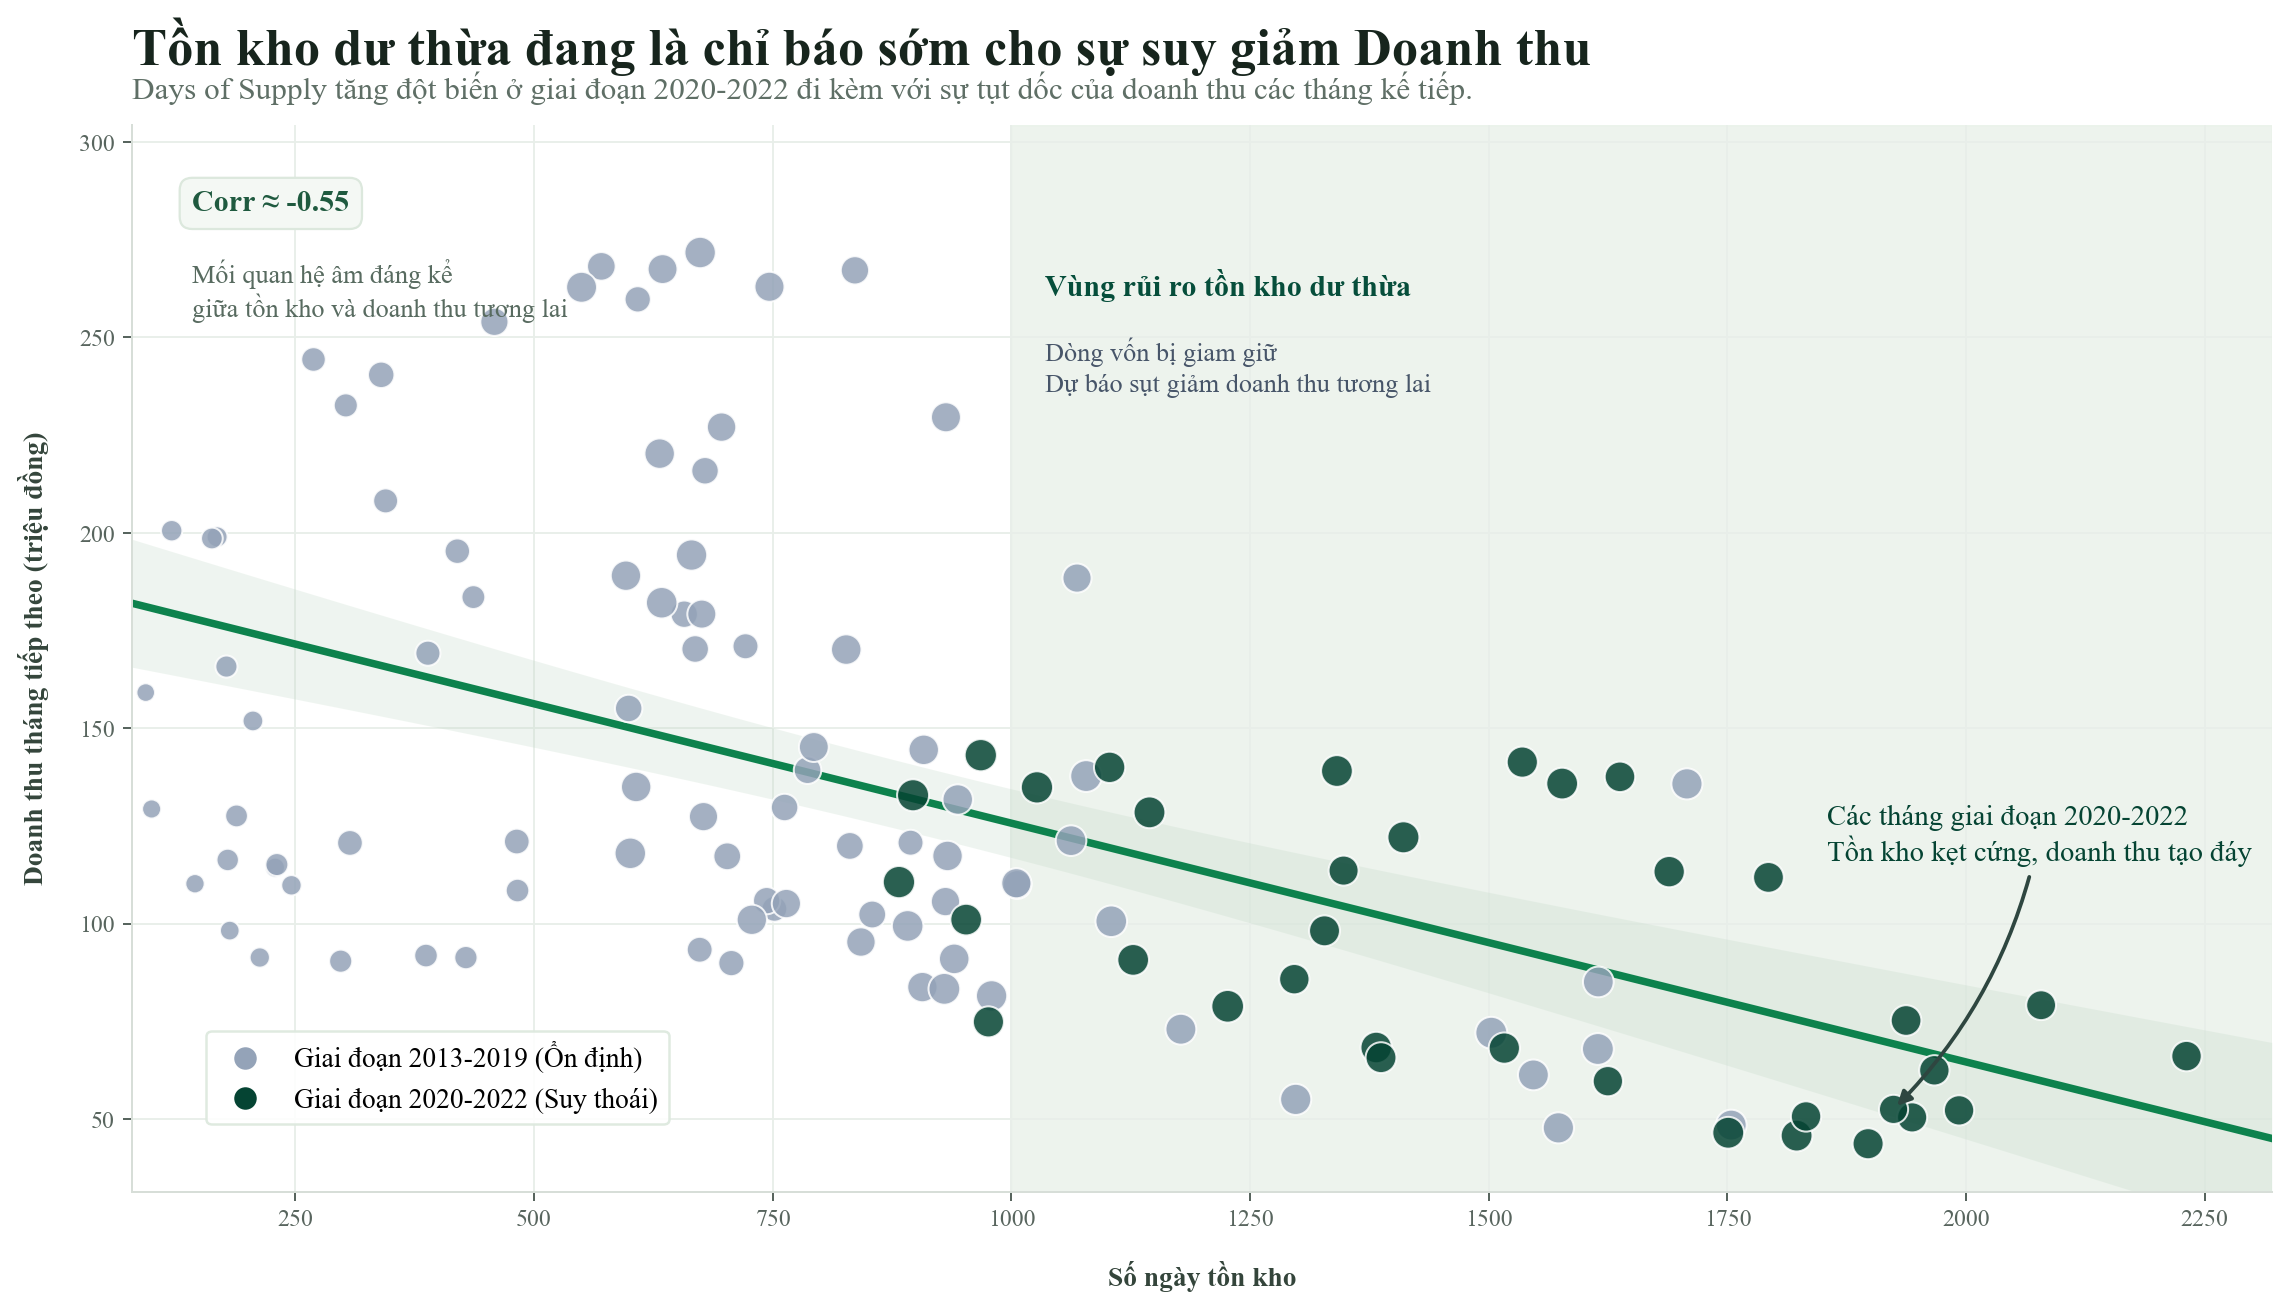

In [133]:
create_chart()